In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

# Venus' Altitudinal Composition Variation

The pressure and temperature variations in Venus' atmosphere are given in ```GGchem/structures/VenusHighResFit.dat```.

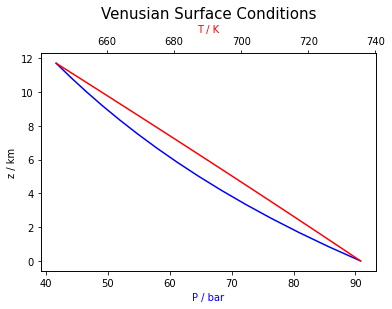

In [4]:
venus_structure = pd.read_csv('../GGchem/structures/VenusHighResFit.dat',
                              delim_whitespace=True,
                             index_col=0)[1:].set_index('z[km]')
venus_structure = venus_structure[venus_structure.index < 12]

fg, ax = plt.subplots()
ax2 = ax.twiny()

ax2.plot(
    venus_structure['T[K]'],
    venus_structure.index,
    c='r',
)

ax.plot(
    venus_structure['P[bar]'],
    venus_structure.index,
    c='b',
)

ax2.set_xlabel('T / K', color='r')
ax.set_xlabel('P / bar',
              color='b')
# ax2 = ax.secondary_yaxis(
#     'right', 
#     functions=(
#         interp1d(
#             np.array(venus_structure.index),
#             np.array(venus_structure['P[bar]']),
#             fill_value='extrapolate'
#         ),
#         interp1d(
#             np.array(venus_structure['P[bar]']),
#             np.array(venus_structure.index),
#             fill_value='extrapolate'
#         )
#     )
# )
ax.set_ylabel('z / km')
ax.set_title('Venusian Surface Conditions', fontsize=15);

The highest point on Venus' surface is Skadi Mons, at $12$km; the lowest is Diana Chasma, at $-2$km. The file goes from 0 to 250km, so we will make a new file to interpolate/extrapolate to Venus' surface conditions.

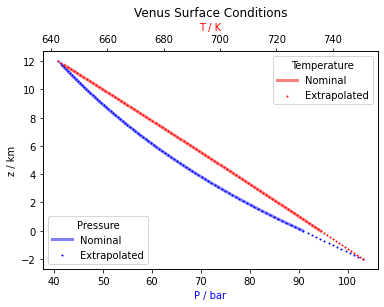

In [23]:
z_km = np.linspace(-2,12,100)
T_K = interp1d(
    venus_structure.index,
    venus_structure['T[K]'],
    fill_value='extrapolate'
)(z_km)
P_bar = interp1d(
    venus_structure.index,
    venus_structure['P[bar]'],
    fill_value='extrapolate'
)(z_km)

fg, ax = plt.subplots()
ax2 = ax.twiny()

ax.scatter(
    P_bar, z_km,
    c='b', s=1, label='Extrapolated'
)
ax.plot(
    venus_structure['P[bar]'], venus_structure.index,
    c='b', alpha=.5, lw=3, label='Nominal'
)
ax2.scatter(
    T_K,z_km,
    c='r', s=1, label='Extrapolated'
)
ax2.plot(
    venus_structure['T[K]'], venus_structure.index,
    c='r', alpha=.5, lw=3, label='Nominal'
)
ax.set_xlabel('P / bar', color='b')
ax2.set_xlabel('T / K', color='r')
ax.set_ylabel('z / km');
ax.set_title('Venus Surface Conditions')

ax.legend(loc='lower left', title='Pressure')
ax2.legend(loc='upper right', title='Temperature');

We now create a file like ```VenusHighResFit.dat```, but with these inter-/extrapolated $p$-$T$ profiles, so that GGchem can run on those conditions.

In [47]:
with open('../GGchem/structures/VenusHighResFit.dat', 'r') as f:
    text = f.read()

extrapolated_profile_filetext = text.split('\n')[0] + '\n' # Headers
extrapolated_profile_filetext += f' {int(len(z_km))}\n' # Number of rows

for i, (z, P, T) in enumerate(zip(z_km, P_bar, T_K)):
    extrapolated_profile_filetext += (' '*(4-len(str(i)))) + f'{str(i)} {z:e} {P:e} {T:e} \n'

with open('../GGchem/structures/VenusSurfaceExtrapFit.dat','w') as f:
    f.write(extrapolated_profile_filetext)